In [1]:
import sklearn
print("scikit-learn installed successfully")

scikit-learn installed successfully


In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [3]:
train = pd.read_csv("../data/processed/train_data.csv")
test = pd.read_csv("../data/processed/test_data.csv")

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

train = train.set_index("Date")
test = test.set_index("Date")

print(train.shape)
print(test.shape)

(1536, 21)
(385, 21)


In [4]:
y_train = train["target"]
y_test = test["target"]

#### Prediction = Previous day's Close price

In [5]:
y_pred = test["Close"].shift(1)

In [6]:
y_test = y_test.iloc[1:]
y_pred = y_pred.iloc[1:]

In [7]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 97.81601270039876


In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 126.59456199963456


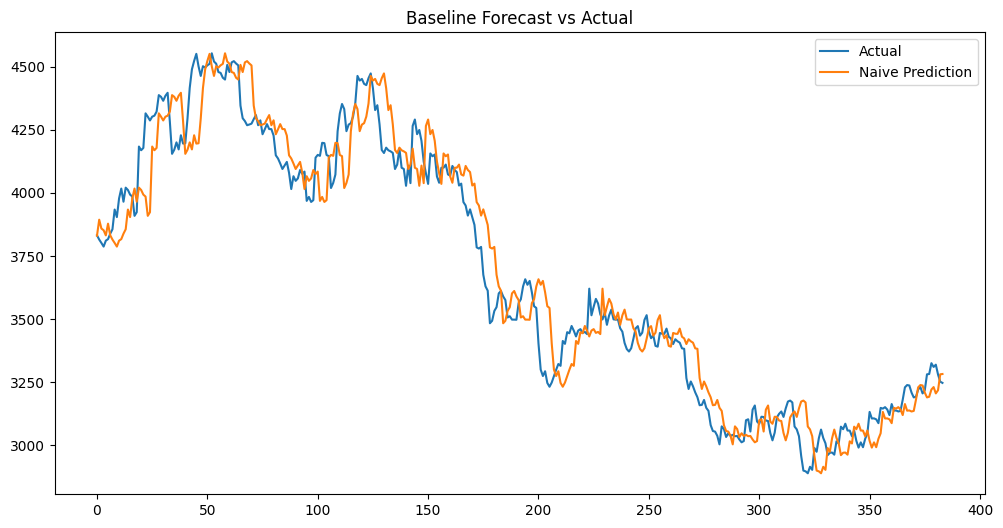

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred.values, label="Naive Prediction")

plt.title("Baseline Forecast vs Actual")

plt.legend()

plt.show()

In [11]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
})

results.to_csv("../data/processed/baseline_predictions.csv")